In [1]:
from nucleotide_sequences import *
from splice_model   	  import *
from gene                 import *
from sequencing           import *

from matplotlib.pyplot    import subplots
from numpy.random         import randint, poisson
from os                   import getcwd, path

# Ivoforms

A package dedicated to the simulation of sequencing read data corresponding to randomly generated genes with predifined splice-models for the evaluation of transcriptome assembly tools

## 1. Generating random exons

The random_nucleotide_sequences module contains classes that allow the generation of various randomly produced nucleotide sequences with length predifined GC-content.
This includes genomic exon sequences that can be transcribed. Nucleotide_sequences can be stored in fasta format using their method nucleotide_sequence.to_fasta(file, id)

In [2]:
min_exon_length = 10
max_exon_length = 20
number_of_exons = 6
gc_content      = 0.4

exons = [Random_exon(randint(min_exon_length, max_exon_length), gc_content=gc_content) for i in range(number_of_exons)]
print('Random exons:')
out = [print(f'\n{i}\n{exon.info()}') for i, exon in enumerate(exons)]

Random exons:

0
Sequence:   CGAATTTCATT
Type:       <class 'nucleotide_sequences.Random_exon'>
Length:     11

1
Sequence:   CGGTAGACTATTTGAA
Type:       <class 'nucleotide_sequences.Random_exon'>
Length:     16

2
Sequence:   CCCAAGGAGT
Type:       <class 'nucleotide_sequences.Random_exon'>
Length:     10

3
Sequence:   ACCGAGGTGTTATTAA
Type:       <class 'nucleotide_sequences.Random_exon'>
Length:     16

4
Sequence:   TGCCAGCGATGTCG
Type:       <class 'nucleotide_sequences.Random_exon'>
Length:     14

5
Sequence:   GGCGGTTTGAGTCCAT
Type:       <class 'nucleotide_sequences.Random_exon'>
Length:     16


## 2. Defining a splice graph

The The splice_model module contains a class that allows to define stochastic model of the splicing process.

The splicing process is characterized by:

1. $\vec{p}$, a probabilty vector. $\vec{p}_i$ is the probability that exon $i$ is the first exon of the resulting transcription
2. $T$, a matrix. $T_{i,j}$ is the probability that exon $i$ will be succeded by exon $j$ in the transcript. The corresponding splice graph must be connected and free of circles.

The input is checked on initialization and if incorrect an error with specific error message is risen.

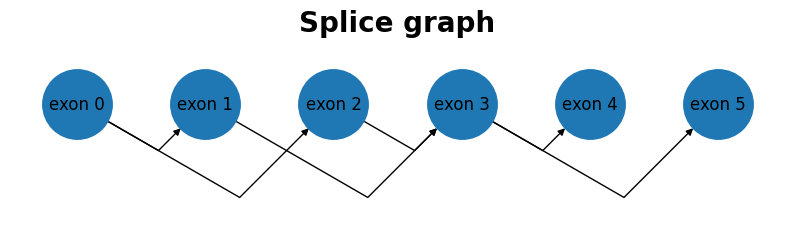

In [3]:
p = [  0.5,  0.5,    0,    0,    0,    0]
T = [
    [    0,  0.5,  0.5,    0,    0,    0],
    [    0,    0,    0,    1,    0,    0],
    [    0,    0,    0,    1,    0,    0],
    [    0,    0,    0,    0, 0.75, 0.25],
    [    0,    0,    0,    0,    0,    0],
    [    0,    0,    0,    0,    0,    0]
    ]

splice_model = Splice_model(p, T)

fig, axes = subplots(figsize=(10,2.5))
splice_model.plot_graph(axes)

## 3. Creating and transcribing a gene

The module contains a class that allows to define a a gene with a list of exons and a splice model.

From the gene we can than generate either a list of all transcript isoforms of the gene or a random single isoform acoording to the splice model.

### 3.1. Creating a gene

In [4]:
gene = Gene(exons, splice_model)

### 3.2. Transcription of the gene

In [5]:
all_isoforms = gene.all_isoforms()
out = [print(f'\n{i}\n{isoforms.info()}') for i, isoforms in enumerate(all_isoforms)]


0
Sequence:   CGGTAGACTATTTGAAACCGAGGTGTTATTAATGCCAGCGATGTCG
Type:       <class 'nucleotide_sequences.Transcript'>
Length:     46

1
Sequence:   CGGTAGACTATTTGAAACCGAGGTGTTATTAAGGCGGTTTGAGTCCAT
Type:       <class 'nucleotide_sequences.Transcript'>
Length:     48

2
Sequence:   CGAATTTCATTCCCAAGGAGTACCGAGGTGTTATTAATGCCAGCGATGTCG
Type:       <class 'nucleotide_sequences.Transcript'>
Length:     51

3
Sequence:   CGAATTTCATTCCCAAGGAGTACCGAGGTGTTATTAAGGCGGTTTGAGTCCAT
Type:       <class 'nucleotide_sequences.Transcript'>
Length:     53

4
Sequence:   CGAATTTCATTCGGTAGACTATTTGAAACCGAGGTGTTATTAATGCCAGCGATGTCG
Type:       <class 'nucleotide_sequences.Transcript'>
Length:     57

5
Sequence:   CGAATTTCATTCGGTAGACTATTTGAAACCGAGGTGTTATTAAGGCGGTTTGAGTCCAT
Type:       <class 'nucleotide_sequences.Transcript'>
Length:     59


In [6]:
random_transcript = gene.transcribe()

print(random_transcript.info())

Sequence:   CGAATTTCATTCCCAAGGAGTACCGAGGTGTTATTAATGCCAGCGATGTCG
Type:       <class 'nucleotide_sequences.Transcript'>
Length:     51


### 3.2. Save your transcripts in .fasta-files



In [7]:
filepath = path.join(getcwd(), "mytranscripts.fasta.txt")

for i, transcript in enumerate(all_isoforms):
    transcript.to_fasta(filepath, f'Transcript {str(i)}')

## 4. The sequencing module

The sequencing modules provides classes that allow to simulate sequencing processes

### 4.1 Long reads

In [8]:
fragmentation_rate = 0.01
substitution_rate  = 0.1
indel_rate         = 0.1

sequencer = Long_read_sequencer(fragmentation_rate, substitution_rate, indel_rate)

print(f'Sequence:\n{random_transcript.info()}\n')
read = sequencer.sequence(random_transcript, verbose=True)
print(f'\nRead:\n{read.info()}\n')
print(len(read.sequence))

Sequence:
Sequence:   CGAATTTCATTCCCAAGGAGTACCGAGGTGTTATTAATGCCAGCGATGTCG
Type:       <class 'nucleotide_sequences.Transcript'>
Length:     51

CGAATTTCATTCCCAAGGAGT C GAGGTGTTATTAATGCCAGCGATGTCG
* **** ********* ***  * **************** ** ******
CAAATT CATTCCCAACGAGUACCGAGGTGTTATTAATGCUAGUGATGTC

Read:
Sequence:   CAAATTCATTCCCAACGAGUCACACGAGGTGTTATTAATGCUAGUGATGTC
Type:       <class 'nucleotide_sequences.Transcript'>
Length:     51

51


### 4.2. Short reads

**TODO**

### 4.3. Simulation of a sequencing experiment

In [9]:
transcripts  = all_isoforms # Assuming all isoforms are present
coverage     = 10           # Mean coverage per nucleotide
min_readlen  = 10           # Minimal read length. Reads with a length below this threshold are discarded
distribution = poisson      
filepath     = path.join(getcwd(), "myreads.fasta.txt")

# Generating reads
reads = []
for transcript in transcripts:
    number_of_read_nucleotides = 0
    to_cover                   = distribution(coverage)*len(transcript.sequence)
    while number_of_read_nucleotides < to_cover:
        read = sequencer.sequence(transcript, verbose=False)
        reads.append(read)
        number_of_read_nucleotides += len(read.sequence)

# Filter reads with suffiecient length
reads = [read for read in reads if len(read.sequence)>=min_readlen]

# Save reads
for i, read in enumerate(reads):
    read.to_fasta(filepath, f'Read {str(i)}')

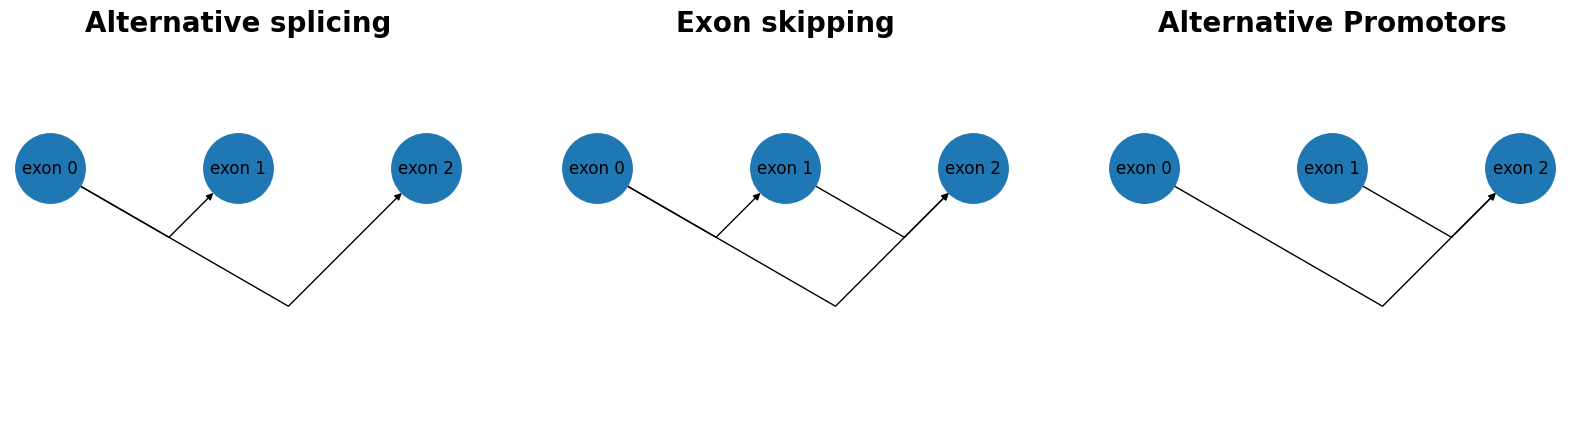

In [10]:
splice_models = []
names         = []

# Alternative splicing
p = [1,0,0]
T = [
    [ 0, 0.5, 0.5],
    [ 0,   0,   0],
    [ 0,   0,   0]]

splice_models.append(Splice_model(p, T))
names.append('Alternative splicing')

# Exon skipping
p = [1,0,0]
T = [
    [ 0, 0.5, 0.5],
    [ 0,   0,   1],
    [ 0,   0,   0],
    ]

splice_models.append(Splice_model(p, T))
names.append('Exon skipping')

# Alternative Promotors
p = [0.5,0.5,0]
T = [
    [ 0,   0,   1],
    [ 0,   0,   1],
    [ 0,   0,   0],
    ]

splice_models.append(Splice_model(p, T))
names.append('Alternative Promotors')

fig, axes = subplots(1, len(splice_models), figsize=(20,5))
for i, splice_model in enumerate(splice_models):
    splice_model.plot_graph(axes[i], names[i])
